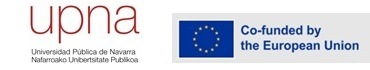

<div style="text-align:center"; font-size: 20px;>
    
# Geospatial Data Analysis

</div>

**Author:** Naziru Halilu


## TOPIC 6: Supervised Classification using Python

In this practical session, you will learn how to perform **supervised classification** using Python. We will start by exploring and cleaning a Sentinel-2 dataset, creating unique parcel identifiers, and organizing the reflectance data across multiple acquisition dates. You will then prepare the data for a **Random Forest classifier**, train the model, evaluate its performance using metrics such as accuracy, F1-score, and confusion matrices, and finally visualize the results both in plots and on interactive maps. This exercise will help you understand the full workflow of supervised classification in a real-world agricultural remote sensing context.

**Inputs required:** The exercise uses a CSV file obtained from **Google Earth Engine**, containing parcel-level Sentinel-2 reflectance data across multiple dates, along with crop type and geometry information. This CSV was generated from the original CSV used in the practical session of **Topic 1**, and processed in GEE using the code from the practical session of **Topic 3**.

### 1. Import libraries

In this cell, we import all the necessary Python libraries for the practice. These libraries are used for:

1. **Data handling and geospatial operations**:
   - `pandas` and `geopandas` for working with tabular and spatial data.
   - `shapely` for handling geometric shapes like polygons.
   - `json` and `os` for file handling.

2. **Machine learning and classification**:
   - `sklearn.ensemble.RandomForestClassifier` to train a supervised classification model.
   - `sklearn.model_selection.train_test_split` to split data into training and testing sets.
   - `GridSearchCV` to perform hyperparameter tuning using cross-validation.
   - `sklearn.metrics` to evaluate model performance (accuracy, F1-score, confusion matrix, etc.).

3. **Visualization**:
   - `matplotlib.pyplot` for plotting results and charts.
   - `folium` for interactive maps.
   - `shapely.geometry.mapping` to convert geometries for visualization in Folium.

By importing these libraries, we set up the environment needed for handling spatial data, training classification models, and visualizing results.


In [ ]:
# Import libraries for handling files and data
import os                  # To interact with the operating system (e.g., file paths)
import json                # To read and write JSON files
import pandas as pd        # For tabular data manipulation
import geopandas as gpd    # For spatial/geospatial data handling
from shapely.geometry import shape  # For creating/manipulating geometric objects

# Libraries for supervised classification
from sklearn.ensemble import RandomForestClassifier  # Random Forest classifier for supervised learning
from sklearn.model_selection import train_test_split, GridSearchCV  # Split data and tune hyperparameters
from sklearn.metrics import (
    confusion_matrix,      # Confusion matrix
    accuracy_score,        # Accuracy metric
    classification_report, # Detailed classification report
    ConfusionMatrixDisplay # To visualize confusion matrices
)

# Libraries for visualization
import matplotlib.pyplot as plt    # Standard plotting library
import folium                      # Interactive maps library
from shapely.geometry import mapping  # Convert shapely geometries into GeoJSON format for Folium


In [ ]:
import warnings
warnings.filterwarnings('ignore')

### 2. Prepare directories

In this cell, we define the paths to the data files we will use in the practice:

1. `DIR_PATH`: This is the folder where your data files are stored. Make sure to update it to your own directory if your files are elsewhere.
2. `CSV_NAME`: The name of the CSV file that contains the dataset with the features and labels for classification.

By setting these variables, we can easily load the data later in the notebook without hardcoding the file paths multiple times.


In [ ]:
# Define the folder path where the dataset is located
DIR_PATH = r'C:\Users\alumno\Desktop\Topic_6' # Use raw string (r'') to avoid issues with backslashes
# Define the name of the CSV file containing the dataset
CSV_NAME = 'Sentinel2_PlotStatistics_MovingAverage.csv'

### 3. Open and clea the dataframe

#### 3.1. Data load and visualization

The next step is to load the dataset into a pandas Dataframe and inspect its basic structure. We print the number of rows and columns to understand the size of the daaset. 
This step is important to get familiar with the dataset before starting preprocessing and classification.

In [ ]:
# Load the dataset CSV into a pandas DataFrame
df = pd.read_csv(os.path.join(DIR_PATH, CSV_NAME))  # Combines directory path and CSV file name
# Print the shape of the DataFrame: number of rows and columns
print('This df has', df.shape[0], 'rows and', df.shape[1], 'columns.')
# Display the first 5 rows to inspect the data
df.head(5)  # Useful to check column names, data types, and example values

#### 3.2. Creating a Unique parcel ID

We are now going to generate a unique identifier (parcelID) for each parcel in the dataset:

1. We first ensure that the columns `MUNICIPIO`, `POLIGONO`, `PARCELA`, and `RECINTO` are integers and then convert them to strings. This guarantees a consistent format for concatenation.
2. Using `agg('-'.join, axis=1)`, we combine these four columns into a single string for each row, creating a `parcelID` that uniquely identifies each parcel.
3. Finally, we check the number of unique parcel IDs to make sure all parcels are correctly identified.

Having a unique ID is essential for linking spatial data (like geometries) with the attribute data later.

In [ ]:
#Check the columns of the dataframe
df.columns

In [ ]:
# Convert relevant columns to integers, then to strings to ensure consistency for concatenation
for column in ['MUNICIPIO','POLIGONO','PARCELA','RECINTO']:
    df[column] = df[column].astype(int).astype(str)  # Ensures no decimal points and string format
# Clean up loop variable (optional)
del column
# Combine the four columns into a single string separated by '-' to create a unique ID
df['parcelID'] = df[['MUNICIPIO','POLIGONO','PARCELA','RECINTO']].agg('-'.join, axis=1)
# Print the number of unique parcel IDs
print(len(df['parcelID'].unique()), 'unique parcel IDs.')
# Display the first 5 rows to verify the new 'parcelID' column
df.head(5)

#### 3.3.  Adjust Geometry Column and Converting to GeoDataFrame

In this cell, we prepare the spatial data for analysis:

1. **Create a geometry column**: The `.geo` column contains geometry information as a JSON string. We use `json.loads()` and `shapely.geometry.shape()` to convert it into a proper geometry object that GeoPandas can understand.
2. **Convert to GeoDataFrame**: Using `gpd.GeoDataFrame()`, we convert the pandas DataFrame to a GeoDataFrame and specify the CRS (Coordinate Reference System) as `EPSG:4326` (WGS84 latitude/longitude).
3. **Drop the original `.geo` column** since we now have a usable geometry column.
4. **Change CRS**: For metric calculations, we reproject the data to `EPSG:25830` (UTM zone 30N for Spain).
5. **Calculate parcel area**: Using the `geometry.area` attribute, we compute the area of each parcel in hectares (`m² / 10,000`).

This step is crucial for linking spatial geometries with attributes and performing spatial operations like area calculations.


In [ ]:
# Convert the '.geo' JSON string to a Shapely geometry object
df['geometry'] = df['.geo'].apply(lambda x: shape(json.loads(x)))
'''
geometry_list = []
for geo_str in df['.geo']:
    geom = shape(json.loads(geo_str))
    geometry_list.append(geom)
df['geometry'] = geometry_list
'''

In [ ]:
# Convert the pandas DataFrame into a GeoPandas GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')  # WGS84 CRS for latitude/longitude
# Display first 5 rows to verify the new geometry column
gdf.head(5)

In [ ]:
# Print current CRS
print('Initial CRS:', gdf.crs)
# Reproject the GeoDataFrame to a metric CRS (UTM zone 30N) for accurate area calculations
gdf_25830 = gdf.to_crs('EPSG:25830')
print('New CRS:', gdf_25830.crs)

In [ ]:
# Calculate parcel area in hectares (1 ha = 10,000 m²)
gdf_25830['area_ha'] = gdf_25830['geometry'].area / 10000
# Display first 5 rows to verify the area calculation
gdf_25830.head(5)

#### 3.4. Translating Crop Names from Spanish to English

1. **Check unique crop names**: Use `gdf['ClasEsp'].unique()` to see all the crop types in Spanish.
2. **Create a translation dictionary**: We map each Spanish crop name to its English equivalent.
3. **Create a new column 'Crop'**: Use the `.map()` function to apply the translation to all rows.
4. **Remove the original Spanish column**: Once translated, the `ClasEsp` column is no longer needed.

This step ensures that the crop names are easy to interpret in subsequent analysis and plots.


In [ ]:
# Check all unique crop names in the dataset (in Spanish)
gdf_25830['ClasEsp'].unique()  

In [ ]:
# Dictionary to translate crop names from Spanish to English
crop_translation = {'TRIGO':'WHEAT', 'SUPERFICIES FORESTALES':'FOREST', 'PASTOS ARBUSTIVOS':'SHRUB', 
                          'CEBADA':'BARLEY','BARBECHO':'FALLOW', 'VIÑA':'VINEYARD', 'ALMENDROS':'ALMONDS', 
                          'MAÍZ':'CORN', 'GUISANTE':'PEA', 'COLZA':'RAPE','GIRASOL':'SUNFLOWER', 'PASTOS HERBÁCEOS':'GRASS', 
                          'PASTOS ARBOLADOS':'SHRUB','OLIVAR':'OLIVE','FRUTALES':'FRUIT-TREES',
                          'HORTÍCOLA DE VERANO':'SUMMER-VEGETABLES', 'ALFALFA':'ALFALFA'}

In [ ]:
# Apply the translation dictionary to create a new 'Crop' column
gdf_25830['Crop'] =gdf_25830['ClasEsp'].map(crop_translation)
'''
crop_in_english_list = []
for crop in gdf_25830['ClasEsp']:
    crop_in_english = crop_translation.get(crop,None) # Returns None if the crop is not in the dictionary
    crop_in_english_list.append(crop_in_english)
gdf_25830['Crop'] = crop_in_english_list
# '''
# Display first 5 rows to verify the translation
gdf_25830.head(5)

#### 3.5. Simplifying the Date Column

We modify the temporal information in the dataset:

1. **Current format**: The 'date' column likely contains timestamps in the format `YYYY-MM-DDTHH:MM:SS`.
2. **Objective**: Keep only the date part (`YYYY-MM-DD`) and discard the time, since it is not relevant for this classification exercise.
3. **Method**: Use the `.str.split('T')` method to split the string at the 'T' character and keep only the first element (the date).


In [ ]:
# Split the 'date' column at 'T' and keep only the first part (YYYY-MM-DD)
gdf_25830['new_date'] = gdf_25830['date'].str.split('T').str[0]
'''
new_dates = []
for date in gdf_25830['date']: 
    new_dates.append(date.split('T')[0])
gdf_25830['new_dates'] = new_dates
'''
# Display the dataframe to verify the change
gdf_25830.head(5)

#### 3.6. Selecting Relevant Columns

In this step, we simplify the dataset by keeping only the columns that are important for our classification task:

1. **Identification**: `parcelID` uniquely identifies each parcel.
2. **Target variable**: `Crop` is what we want to predict (the type of crop).
3. **Date**: `date` may be useful for temporal analysis.
4. **Spectral bands**: `Blue, Green, Red, RE1-RE4, NIR, SWIR1, SWIR2` are Sentinel-2 bands used as input features for classification.
5. **Additional info**: `area_ha` for the size of the parcel and `geometry` for spatial representation.

We create a new GeoDataFrame with just these relevant columns.


In [ ]:
#check the name of the columns of our dataframe
gdf_25830.columns

In [ ]:
# List of Sentinel-2 spectral bands that we will use as features
band_names = ['Blue','Green','Red', 'RE1', 'RE2', 'RE3', 'RE4','NIR','SWIR1', 'SWIR2']
# Select only the relevant columns for classification
gdfclas = gdf_25830[['parcelID','Crop','new_date'] + band_names + ['area_ha','geometry']]
# Display the first 5 rows to verify
gdfclas.head(5)

### 4. Organize the data for Classification

In the original CSV, each row corresponds to a single parcel at a single date. However, for supervised classification using a Random Forest model, we need the dataset structured so that:

- **Each row represents one parcel**, not one date.
- **Each column contains the reflectance values for a specific band at a specific date**.

We will also:
- Remove very small parcels (<1 ha) to avoid noisy data.
- Keep track of total and removed areas for understanding data coverage.

In [ ]:
# --- Step 1: Get all unique dates in the dataset ---
dates = gdfclas['new_date'].unique()  # List of acquisition dates
dates

In [ ]:
# --- Step 2: Organize the data of the dataframe ---
# Pivot the table: rows = parcelID, columns = band_date, values = reflectance
gdfclas_pivot = gdfclas.pivot_table(
    index=['parcelID','Crop','area_ha'],  # keep these as identifiers
    columns='new_date', 
    values=band_names
)
print('Our new dataframe has now',len(gdfclas_pivot),'rows.')
gdfclas_pivot.head(5)

In [ ]:
#Create a list with the new names of the columns
new_column_names = [f'{band}_{date}' for band, date in gdfclas_pivot.columns]
'''
new_column_names = []
for band, date in gdfclas_pivot.columns:
    new_column_names.append(f'{band}_{date}')
new_column_names
'''
new_column_names

In [ ]:
#Flatten the multi-level columns (band, date) to 'band_date'
gdfclas_pivot.columns = new_column_names
gdfclas_pivot.head(5)

In [ ]:
# Reset the index so parcelID and area_ha can be accessed as regular columns
gdfclas_pivot = gdfclas_pivot.reset_index()
gdfclas_pivot.head(5)

In [ ]:
# Add geometry data
gdfclas_pivot = gdfclas_pivot.merge(gdfclas[['parcelID','geometry']].drop_duplicates(), on = 'parcelID', how = 'inner')
gdfclas_pivot.head(5)

In [ ]:
# --- Setp 3 : Remove small parcels ---
min_parcel_size = 1
gdfclas_bigparcels = gdfclas_pivot.loc[gdfclas_pivot['area_ha'] >= min_parcel_size]
gdf_removed_parcels = gdfclas_pivot.loc[gdfclas_pivot['area_ha'] < min_parcel_size]
# Calculate data of interest
removed_parcels = len(gdf_removed_parcels)
removed_area = gdf_removed_parcels['area_ha'].sum()
remaining_area = gdfclas_bigparcels['area_ha'].sum()
print('{} parcels were removed ({:.1f} ha).'.format(removed_parcels,removed_area))
print('{} parcels remained: {:.1f} ha ({:.1f}% of the initial study area).'.format(len(gdfclas_bigparcels),remaining_area,100*remaining_area/(remaining_area+removed_area)))

In [ ]:
gdfclas_bigparcels.head(5)

#### Descriptive Analysis and Data Cleaning

Before feeding data into a machine learning classifier, it is important to understand the dataset:

1. **Number of parcels and total area per crop** – This helps identify which crops are well-represented and which might be too rare for reliable modeling.
2. **Selecting representative classes** – We will only keep crops that have a minimum number of parcels to avoid sparse classes.
3. **Encoding crop names to numbers** – Machine learning classifiers require numerical labels instead of text.
4. **Handling missing data (NaNs)** – Any column with missing values is removed to ensure the classifier receives complete information.


In [ ]:
# --- Step 1: Analyze number of parcels and total area per crop ---
parcel_info = gdfclas_bigparcels.groupby('Crop').agg(
    num_parcels=('Crop', 'size'),  # Count how many parcels belong to each crop
    total_ha=('area_ha', 'sum')    # Sum the area for each crop
).reset_index()
# Display information
parcel_info.sort_values('total_ha',ascending = False).reset_index(drop = True)

In [ ]:
# --- Step 2: Keep only representative crops ---
min_parcels = 5  # Minimum number of parcels to consider a class representative
representative_crops = parcel_info.loc[parcel_info['num_parcels'] >= min_parcels, 'Crop'].values
print('Our representative classes are:', representative_crops)

# Filter dataframe to include only representative crops
gdfclas_bigparcels_repcrops = gdfclas_bigparcels.loc[gdfclas_bigparcels['Crop'].isin(representative_crops)].reset_index(drop=True)
print('We have now', len(gdfclas_bigparcels), 'parcels.')

In [ ]:
# --- Step 3: Encode crop names as numbers for classifier ---
# Create the dictionary for the encoding
crop_to_number = {crop:number for crop,number in zip(representative_crops,range(1,len(representative_crops)+1))}
number_to_crop = {number:crop for crop,number in zip(representative_crops,range(1,len(representative_crops)+1))}
'''
crop_to_number = {}
for crop, number in zip(representative_crops,range(1,len(representative_crops)+1)):
    crop_to_number[crop] = number
# '''
crop_to_number

In [ ]:
# Apply the translation dictionary to create a new 'Crop' column
gdfclas_bigparcels_repcrops['Crop_number'] = gdfclas_bigparcels_repcrops['Crop'].map(crop_to_number)
'''
crop_in_numbers = []
for crop in gdfclas_bigparcels_repcrops['Crop']:
    crop_in_number = crop_to_number.get(crop,None) # Returns '' if the crop is not in the dictionary
    crop_in_numbers.append(crop_in_number)
gdfclas_bigparcels_repcrops['Crop_number'] = crop_in_numbers
# '''
gdfclas_bigparcels_repcrops.head(5)

In [ ]:
# --- Step 4: Check for NaN values (missing data) ---
# Columns with all NaN
print('Number of columns with all NaN:', gdfclas_bigparcels_repcrops.isna().all().sum())

# Print initial dates
print(len(dates), 'initial dates:', dates)

# Remove columns containing any NaN
gdfclas_nonans = gdfclas_bigparcels_repcrops.dropna(axis=1, how='any')

# Final dates after removing NaNs
final_dates = set([x.split('_')[1] for x in gdfclas_nonans.columns if '-' in x])
'''
final_dates = []
for column in gdfclas_nonans.columns:
    if '-' in column:
        final_dates.append(column.split('_')[1])
final_dates = set(final_dates)
'''
print(len(final_dates), 'final dates:', list(final_dates))

In [ ]:
# Display the first 5 rows of the final dataframe
gdfclas_nonans.head(5)

### 5. Parcel Supervised Classification 

#### 5.1. Preparing Inputs and Splitting the Dataset

Before training a machine learning model, we need to:

1. **Select input features (X)** – These are the reflectance values for all bands and dates.  
2. **Select target labels (y)** – This is the crop class encoded as a number.  
3. **Split the data into training and test sets** – We will use 70% of the parcels for training and 30% for testing.  
   - We use stratification to ensure each crop class is proportionally represented in both train and test datasets.  
   - This helps to evaluate the model fairly and avoid bias toward dominant classes.


In [ ]:
gdfclas_nonans.columns

In [ ]:
# --- Step 1: Select input features for the model ---
# Only keep columns with a '-' in the name (these correspond to band_date features)
model_inputs = [x for x in gdfclas_nonans.columns if x not in ['parcelID', 'Crop', 'area_ha','Crop_number','geometry']]
'''
model_inputs = []
for column in gdfclas_nonans.columns:
    if column not in ['parcelID', 'Crop', 'area_ha','Crop_number']:
        model_inputs.append(column)
'''
X = gdfclas_nonans[model_inputs]  # Input features for the classifier
y = gdfclas_nonans['Crop_number']  # Target labels (encoded crop classes)

In [ ]:
# Display the model inputs:
X.head(5)

In [ ]:
# Display the target labels
y.head(5)

In [ ]:
# --- Step 2: Split the dataset into training and testing sets ---
test_size = 0.3  # 30% of the data for testing, 70% for training

# Stratify ensures that the class distribution is similar in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, stratify=y, random_state=12
)

In [ ]:
# --- Step 3: Display the number of parcels in each dataset ---
print('Number of parcels in train dataset (70%):', len(X_train))
print('Number of parcels in test dataset (30%):', len(X_test))

In [ ]:
# Display the datasets
X_train.head(5)

In [ ]:
y_train.head(5)

In [ ]:
X_test.head(5)

In [ ]:
y_test.head(5)

#### 5.2.  Optional: Hyperparameter Optimization with GridSearchCV

Machine learning models, like Random Forests, have parameters that control how they learn. These are called **hyperparameters**.  

- Examples for Random Forest:
  - `n_estimators`: Number of trees in the forest.
  - `max_features`: Maximum number of features considered for splitting each node.
  - `criterion`: Function to measure quality of a split (`gini` or `entropy`).
  - `min_samples_split`: Minimum number of samples required to split an internal node.

Using `GridSearchCV`, we can automatically test many combinations of these hyperparameters and select the combination that gives the **best accuracy**.  

> Note: This process can take a long time, so we will not run it during the class. But this is how you could do it in practice.

MORE INFO.: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html


In [ ]:
'''
# --- Step 1: Define the Random Forest classifier ---
RF = RandomForestClassifier()

# --- Step 2: Define the hyperparameter grid ---
param_grid = {
    'n_estimators': [10,50,100],             # Number of trees
    'max_features': ['sqrt', 'log2', None],    # Max features considered for each split
    'criterion': ['gini', 'entropy'],          # Split quality metric
    'min_samples_split': [2,10,20]              # Minimum samples to split a node
}

# --- Step 3: GridSearchCV to test all combinations ---
classifier = GridSearchCV(
    RF, param_grid, scoring='accuracy', cv=5, return_train_score=True
)

# --- Step 4: Train all models with training data ---
classifier = classifier.fit(X_train, y_train)

# --- Step 5: Show the best hyperparameters and associated accuracy ---
print(classifier.best_params_)
print(classifier.best_score_)
'''

#### 5.3.  Train the Random Forest Classifier and obtain predictions

Now we will train our Random Forest classifier using the hyperparameters we selected (either default or optimized).  

Steps in this cell:

1. **Define the classifier** with the chosen hyperparameters.
2. **Train** it on the training dataset (`X_train` and `y_train`).
3. **Make predictions** for both training and testing datasets.


In [ ]:
# --- Step 1: Define the Random Forest classifier with chosen hyperparameters ---
RF = RandomForestClassifier(
    criterion='gini',          # Measure to evaluate splits
    max_features='sqrt',       # Max features considered for each split
    min_samples_split=2,      # Minimum samples to split a node
    n_estimators=100,           # Number of trees in the forest
    random_state=12            # For reproducibility
)

# --- Step 2: Train the Random Forest with the training data ---
RF.fit(X_train, y_train)

# --- Step 3: Predict classes for train and test datasets ---
prediction_train = RF.predict(X_train)
prediction_test = RF.predict(X_test)

#### 5.4.  Evaluate performance
   - **Accuracy**: Percentage of correctly classified parcels.
   - **Classification report per class**: Shows precision, recall, and F1-score for each crop type.
   - **Confusion matrix**: Helps visualize which classes are most frequently misclassified.
   
MORE INFO.: https://scikit-learn.org/stable/api/sklearn.metrics.html

In [ ]:
# Accuracy: fraction of correctly classified parcels
accuracy_train = accuracy_score(y_train, prediction_train)
accuracy_test = accuracy_score(y_test, prediction_test)

print('Accuracy - Train: {:.3f}, Test: {:.3f}.'.format(accuracy_train, accuracy_test))

In [ ]:
# Detailed classification report per class 
classification_results_per_class = classification_report(
    y_test, prediction_test,
    target_names=representative_crops,
    output_dict=True
)
pd.DataFrame(classification_results_per_class)

In [ ]:
# --- Step 3: Confusion matrix ---
CM = confusion_matrix(y_test, prediction_test)
CM  # Visualize which crops are most often misclassified

### 6. Classification results visualization

#### Visualize the Confusion Matrix

In this cell we will **plot the confusion matrix** to better understand the performance of our classifier.  The confusion matrix shows:

- **Rows**: the true (ground-truth) crop classes.
- **Columns**: the predicted crop classes.
- The diagonal shows the **correct predictions**.
- Off-diagonal cells show **misclassifications**, helping us see which crops are most often confused.

This visual representation is very helpful to analyze where the classifier is making errors.


In [ ]:
# --- Step 1: Define figure size (in cm converted to inches) ---
cm = 1/2.54  # Conversion factor from cm to inches
fig, ax = plt.subplots(figsize=(10*cm, 10*cm))

# --- Step 2: Prepare the confusion matrix display ---
disp = ConfusionMatrixDisplay(
    confusion_matrix=CM,           # The confusion matrix calculated previously
    display_labels=representative_crops  # Crop names instead of numeric labels
)

# --- Step 3: Plot the confusion matrix ---
disp.plot(
    colorbar=False,  # Hide colorbar to simplify visualization
    cmap='Blues',    # Color gradient
    xticks_rotation=90,  # Rotate x-axis labels for better readability
    ax=ax          # Plot in the current axes
)

# --- Step 4: Customize labels and title ---
ax.set_ylabel('Ground-truth values')   # True crop classes
ax.set_xlabel('Predicted values')  # Predicted crop classes
ax.set_title('Confusion matrix')   # Title of the plot

#### Visualize Parcels with True vs Predicted Classes on a Map

In this cell we will create an **interactive map** using Folium to visualize the classification results.  We will display:

- **Ground-truth (observed) classes** for both training and test datasets.
- **Predicted classes** for both training and test datasets.
- Each parcel is colored according to its crop class.
- Tooltips will show the **parcel ID** and the **crop class**.
- You can toggle between layers using the **LayerControl**.

We will also add a **legend** to match colors with crop names. This map helps to visually evaluate where the classifier is performing well and where errors occur.


In [ ]:
# --- Step 1: Create DataFrames for train and test with true/predicted values ---
dfgraf_train = pd.DataFrame({'y_train': y_train, 'prediction_train': prediction_train}, index=y_train.index)
dfgraf_test = pd.DataFrame({'y_test': y_test, 'prediction_test': prediction_test}, index=y_test.index)

# Join parcelID and geometry information from the main dataframe
dfgraf_train = gdfclas_nonans[['parcelID', 'geometry']].join(dfgraf_train, how='inner')
dfgraf_test = gdfclas_nonans[['parcelID', 'geometry']].join(dfgraf_test, how='inner')

# Convert to GeoDataFrames with proper CRS
gdfgraf_train = gpd.GeoDataFrame(dfgraf_train, geometry='geometry', crs='EPSG:25830')
gdfgraf_test = gpd.GeoDataFrame(dfgraf_test, geometry='geometry', crs='EPSG:25830')

#Display the new created geodataframe
gdfgraf_train

In [ ]:
# --- Step 2: Define a color dictionary for each crop class ---
color_dict = {
    1:'#1f77b4', 2:'#ff7f0e', 3:'#2ca02c', 4:'#d62728',
    5:'#9467bd', 6:'#8c564b', 7:'#e377c2', 8:'#7f7f7f',
    9:'#bcbd22', 10:'#17becf', 11:'#a55194', 12:'#393b79'
}

In [ ]:
# --- Step 3: Explode MultiPolygons to separate rows for plotting ---
dfgraf_train_plot = gdfgraf_train.explode(index_parts=False).reset_index(drop=True)
dfgraf_test_plot = gdfgraf_test.explode(index_parts=False).reset_index(drop=True)

In [ ]:
# --- Step 4: Define a helper function to add GeoDataFrames as layers ---
def add_gdf_layer(m, gdf, color_col, layer_name, tooltip_cols=None, color_map=None):
    """
    Add a GeoDataFrame as a Folium layer.
    Parameters:
        m: folium.Map
        gdf: GeoDataFrame (in EPSG:4326)
        color_col: column with the class to determine color
        layer_name: name of the layer
        tooltip_cols: columns to show in the tooltip
        color_map: dictionary mapping class numbers to colors
    """
    layer = folium.FeatureGroup(name=layer_name)
    for _, row in gdf.iterrows():
        # Determine the fill color for this parcel
        color = color_map[row[color_col]] if color_map else 'blue'
        # Create tooltip text from selected columns
        tooltip_text = "<br>".join([f"{col}: {row[col]}" for col in tooltip_cols]) if tooltip_cols else None
        # Map class numbers to crop names for tooltip
        if tooltip_text:
            tooltip_text = tooltip_text.replace('prediction_','Prediction (').replace('y_', 'Ground-truth (')
            tooltip_text = tooltip_text.replace('train','Train)').replace('test','Test)')
            crop_num = int(tooltip_text.split(':')[-1])
            crop_name = number_to_crop[crop_num]
            tooltip_text = ' '.join(tooltip_text.split(' ')[:-1] + [crop_name])
        # Add the parcel polygon to the layer
        folium.GeoJson(
            mapping(row['geometry']),
            style_function=lambda x, color=color: {
                'fillColor': color,
                'color': 'black',
                'weight': 0.1,
                'fillOpacity': 1
            },
            tooltip=tooltip_text
        ).add_to(layer)
    layer.add_to(m)


In [ ]:
# --- Step 5: Prepare the map centered on test dataset ---
dfgraf_test_wgs84 = dfgraf_test_plot.to_crs(epsg=4326)
minx, miny, maxx, maxy = dfgraf_test_wgs84.total_bounds
center = [(miny + maxy)/2, (minx + maxx)/2]

m = folium.Map(location=center, zoom_start=13, tiles=None)

# --- Step 7: Add base maps ---
folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
    attr='Google', name='Google Satellite'
).add_to(m)
folium.TileLayer("OpenStreetMap", name="OSM").add_to(m)
folium.TileLayer("CartoDB positron", name="CartoDB Positron").add_to(m)

# --- Step 8: Add layers for train and test datasets using helper function ---
dfgraf_train_wgs84 = dfgraf_train_plot.to_crs(epsg=4326)
add_gdf_layer(m, dfgraf_train_wgs84, 'y_train', 'Ground-truth (train)',
              tooltip_cols=['parcelID', 'y_train'], color_map=color_dict)
add_gdf_layer(m, dfgraf_train_wgs84, 'prediction_train', 'Predictions (train)',
              tooltip_cols=['parcelID', 'prediction_train'], color_map=color_dict)
add_gdf_layer(m, dfgraf_test_wgs84, 'y_test', 'Ground-truth (test)',
              tooltip_cols=['parcelID', 'y_test'], color_map=color_dict)
add_gdf_layer(m, dfgraf_test_wgs84, 'prediction_test', 'Predictions (test)',
              tooltip_cols=['parcelID', 'prediction_test'], color_map=color_dict)

# --- Step 9: Add layer control to toggle layers ---
folium.LayerControl().add_to(m)

# --- Step 10: Create a legend for crop classes ---
legend_html = """
<div style="
    position: fixed; 
    bottom: 5px; left: 5px; width: 500px; 
    background-color: rgba(255, 255, 255, 0.9);
    border: 1px solid grey;
    z-index:9999; font-size:9px;
    padding: 10px; border-radius: 10px;
">
<div style="display: grid; grid-template-columns: repeat(6, 1fr); grid-gap: 4px; margin-top: 6px;">
"""
for c in sorted(color_dict.keys()):
    class_name = number_to_crop[c]
    legend_html += f"""
    <div style="display: flex; align-items: center;">
        <div style='background:{color_dict[c]}; width:12px;height:12px; margin-right:5px; border:1px solid #555;'></div>
        {class_name}
    </div>
    """
legend_html += "</div></div>"

# Add legend to map
m.get_root().html.add_child(folium.Element(legend_html))

# --- Step 11: Display map ---
m